In [16]:
import sys

import Vares

import pandas as pd
import jax.numpy as jnp
import numpy as np 
import matplotlib.pyplot as plt

In [17]:
df = pd.read_excel('hist.xlsx')
print(df.head())

usd_price = df['USD'].to_numpy()
eur_price = df['EUR'].to_numpy()
cny_price = df['CNY'].to_numpy()

        date      USD      EUR      CNY
0 2019-01-10  67.0795  76.9066  98.1498
1 2019-01-11  66.8605  77.2105  98.6216
2 2019-01-12  66.9167  77.1282  99.1491
3 2019-01-15  67.1920  77.0692  99.4318
4 2019-01-16  67.0820  76.9498  99.3292


In [18]:
#yuan handling 
mask = cny_price > 60 
cny_price[mask] = cny_price[mask]/10 #ensuring cohesion
cny_price

array([ 9.81498,  9.86216,  9.91491, ..., 11.4165 , 11.5581 , 11.3685 ],
      shape=(1667,))

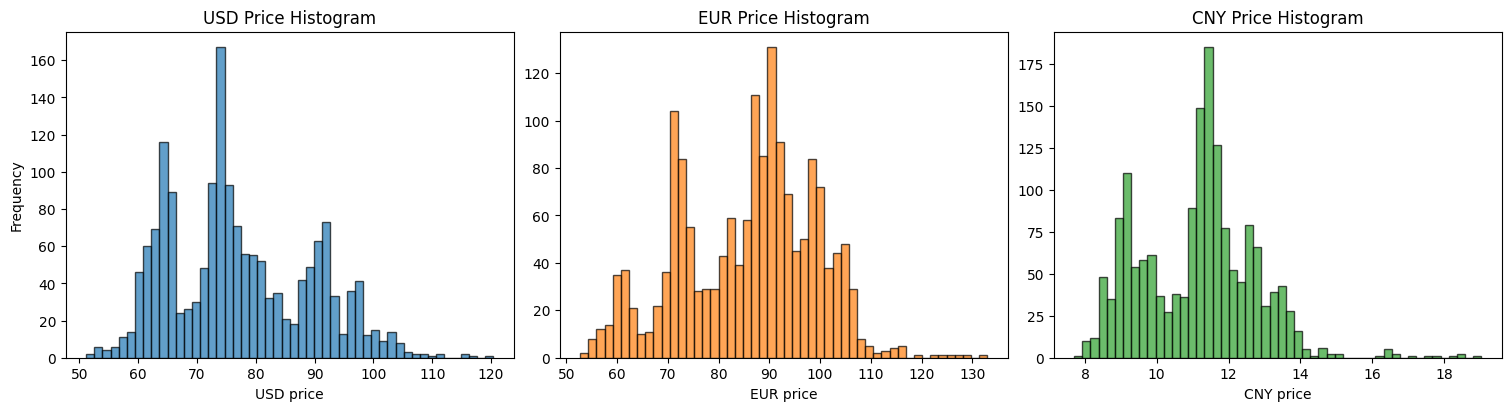

In [19]:
# plot histograms for the three price arrays already present in the notebook
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(usd_price, bins=50, color='tab:blue', edgecolor='k', alpha=0.7)
axes[0].set_title('USD Price Histogram')
axes[0].set_xlabel('USD price')
axes[0].set_ylabel('Frequency')

axes[1].hist(eur_price, bins=50, color='tab:orange', edgecolor='k', alpha=0.7)
axes[1].set_title('EUR Price Histogram')
axes[1].set_xlabel('EUR price')

axes[2].hist(cny_price, bins=50, color='tab:green', edgecolor='k', alpha=0.7)
axes[2].set_title('CNY Price Histogram')
axes[2].set_xlabel('CNY price')

plt.show()

In [20]:
def return_array(prices): 
    rets = np.diff(prices) / prices[:-1]
    rets = jnp.array(rets, dtype='float64')
    return rets 

In [21]:
cny_rets = return_array(cny_price)
usd_rets = return_array(usd_price)
eur_rets = return_array(eur_price)

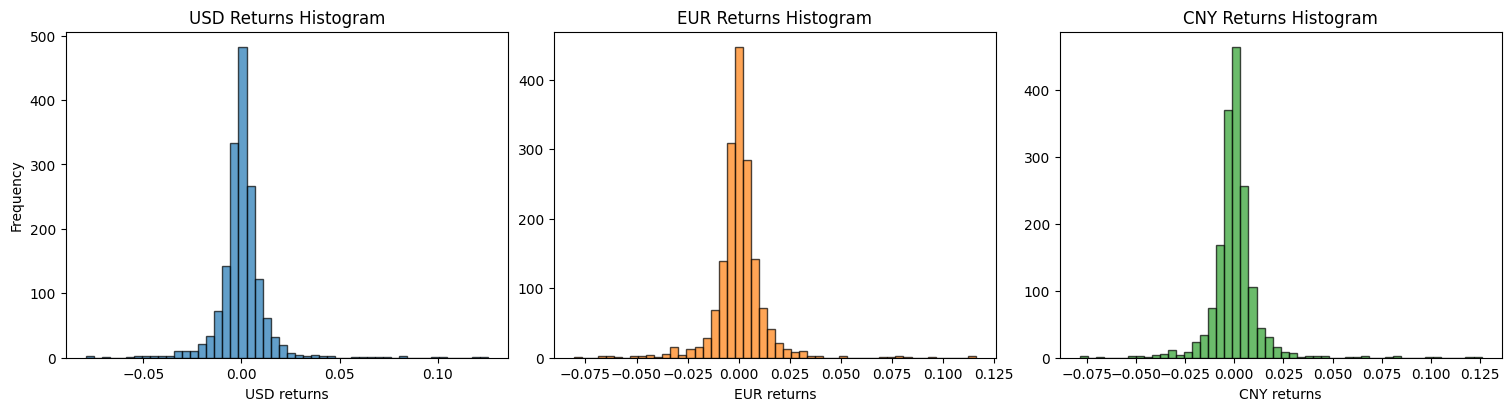

In [22]:
# plot histograms for the three price arrays already present in the notebook
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(usd_rets, bins=50, color='tab:blue', edgecolor='k', alpha=0.7)
axes[0].set_title('USD Returns Histogram')
axes[0].set_xlabel('USD returns')
axes[0].set_ylabel('Frequency')

axes[1].hist(eur_rets, bins=50, color='tab:orange', edgecolor='k', alpha=0.7)
axes[1].set_title('EUR Returns Histogram')
axes[1].set_xlabel('EUR returns')

axes[2].hist(cny_rets, bins=50, color='tab:green', edgecolor='k', alpha=0.7)
axes[2].set_title('CNY Returns Histogram')
axes[2].set_xlabel('CNY returns')

plt.show()

In [23]:
alpha = 0.01
Vares.Test.var_all_methods(cny_rets, alpha, u=.9)

historical_var() took 0.005226s
Historical VaR: 0.03430672012839299
parametric_var_normal() took 0.007728s
Parametric VaR: 0.02852713585555889
garch_var() took 0.027189s
GARCH(1,1) with Normal distribution VaR: 0.025657026267490113
garch_var() took 0.022951s
GARCH(1,1) with Student distribution VaR: 0.03411462528257083
MLE_EVT() took 1.567713s
IMPORTANT 166 1666 0.03660149746661459 0.0004403743740152379 5
EVT VaR 0.09349706330074223


In [24]:
Vares.Test.var_all_methods(usd_rets, alpha, u=.95)

historical_var() took 0.000270s
Historical VaR: 0.03268264690152301
parametric_var_normal() took 0.000422s
Parametric VaR: 0.028770317451891556
garch_var() took 0.010334s
GARCH(1,1) with Normal distribution VaR: 0.02519275402969398
garch_var() took 0.012397s
GARCH(1,1) with Student distribution VaR: 0.03311191147299352
MLE_EVT() took 0.786613s
IMPORTANT 83 1666 0.03669500070791336 -0.022614352415433688 5
!!!!!!!!!!FLAG
EVT VaR 0.07299237084563931


In [25]:
Vares.Test.var_all_methods(eur_rets, alpha, u=.925)

historical_var() took 0.000406s
Historical VaR: 0.03661629868244053
parametric_var_normal() took 0.000501s
Parametric VaR: 0.02943693137268712
garch_var() took 0.011306s
GARCH(1,1) with Normal distribution VaR: 0.020847540213492832
garch_var() took 0.009839s
GARCH(1,1) with Student distribution VaR: 0.027051897078091195
MLE_EVT() took 0.664938s
IMPORTANT 124 1666 0.036681035930805045 -0.019461026921286262 5
!!!!!!!!!!FLAG
EVT VaR 0.08421217404033615


EVT suggests that the data follows normal disitribution, yet historical, parametric and GARCH(1,1) discrepancies do not support that claim

In [26]:
#Generated using VS copilot
from scipy import stats

def test_normality(name, data, alpha=alpha):
    x = np.asarray(data).ravel()
    x = x[~np.isnan(x)]
    n = x.size
    print(f"Normality tests for {name} (n={n}):")

    # Shapiro-Wilk
    try:
        stat, p = stats.shapiro(x)
        print(f" Shapiro-Wilk: stat={stat:.4f}, p={p:.4g} -> {'reject' if p < alpha else 'fail to reject'} H0 (alpha={alpha})")
    except Exception as e:
        print(f" Shapiro-Wilk: failed ({e})")

    # D'Agostino-Pearson (normaltest)
    stat, p = stats.normaltest(x)
    print(f" D'Agostino-Pearson: stat={stat:.4f}, p={p:.4g} -> {'reject' if p < alpha else 'fail to reject'} H0")

    # Jarque-Bera
    stat, p = stats.jarque_bera(x)
    print(f" Jarque-Bera: stat={stat:.4f}, p={p:.4g} -> {'reject' if p < alpha else 'fail to reject'} H0")

    # Anderson-Darling
    res = stats.anderson(x, dist='norm')
    # Try to find the critical value matching alpha (significance levels provided in percent)
    target_pct = alpha * 100
    idxs = np.where(np.isclose(res.significance_level, target_pct))[0]
    if idxs.size:
        cv = res.critical_values[idxs[0]]
        verdict = 'reject' if res.statistic > cv else 'fail to reject'
        print(f" Anderson-Darling: stat={res.statistic:.4f}, critical({int(target_pct)}%)={cv:.4f} -> {verdict} H0")
    else:
        # show all critical values and give conservative interpretation vs 1% level
        print(f" Anderson-Darling: stat={res.statistic:.4f}, critical_values={list(zip(res.significance_level, res.critical_values))}")
        cv_1pct = res.critical_values[-1]  # typically the most stringent (1%)
        verdict = 'reject' if res.statistic > cv_1pct else 'fail to reject'
        print(f"  Interpretation vs 1% level: stat>{cv_1pct:.4f} -> {verdict} H0")

    print("-" * 60)

for name, arr in [('USD', usd_rets), ('EUR', eur_rets), ('CNY', cny_rets)]:
    test_normality(name, arr, alpha)

Normality tests for USD (n=1666):
 Shapiro-Wilk: stat=0.7635, p=9.498e-44 -> reject H0 (alpha=0.01)
 D'Agostino-Pearson: stat=908.6379, p=4.918e-198 -> reject H0
 Jarque-Bera: stat=38997.5624, p=0 -> reject H0
 Anderson-Darling: stat=79.3543, critical(1%)=1.0890 -> reject H0
------------------------------------------------------------
Normality tests for EUR (n=1666):
 Shapiro-Wilk: stat=0.7732, p=4.134e-43 -> reject H0 (alpha=0.01)
 D'Agostino-Pearson: stat=763.0784, p=1.994e-166 -> reject H0
 Jarque-Bera: stat=29230.4120, p=0 -> reject H0
 Anderson-Darling: stat=79.9199, critical(1%)=1.0890 -> reject H0
------------------------------------------------------------
Normality tests for CNY (n=1666):
 Shapiro-Wilk: stat=0.7468, p=8.532e-45 -> reject H0 (alpha=0.01)
 D'Agostino-Pearson: stat=932.6512, p=3.002e-203 -> reject H0
 Jarque-Bera: stat=43422.5007, p=0 -> reject H0
 Anderson-Darling: stat=88.2967, critical(1%)=1.0890 -> reject H0
--------------------------------------------------

Student-t (df=2) QQ for USD (n=1666):


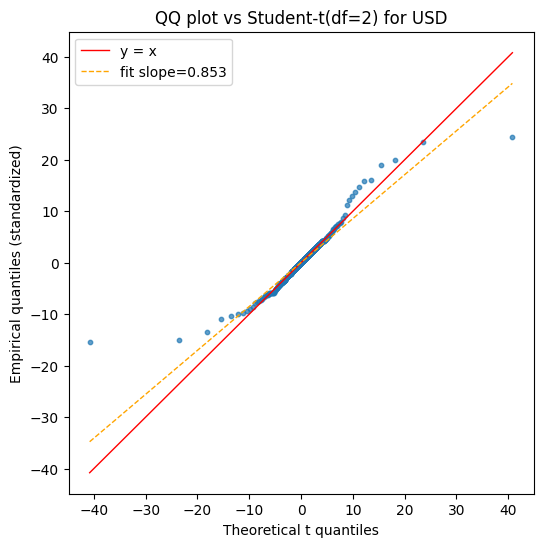

  Fit slope=0.8532, intercept=0.0342
------------------------------------------------------------
Student-t (df=2) QQ for EUR (n=1666):


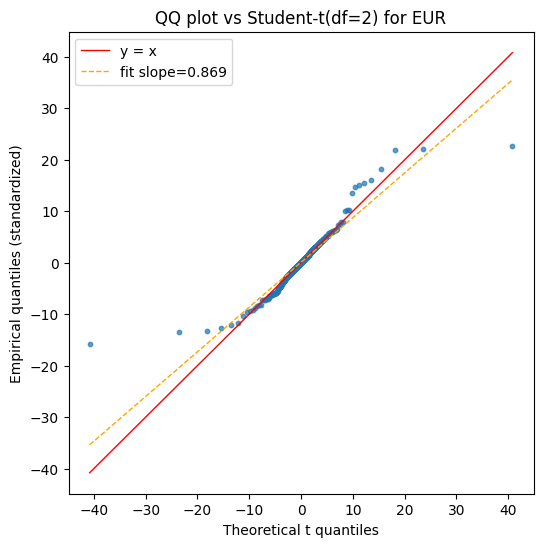

  Fit slope=0.8689, intercept=0.0700
------------------------------------------------------------
Student-t (df=2) QQ for CNY (n=1666):


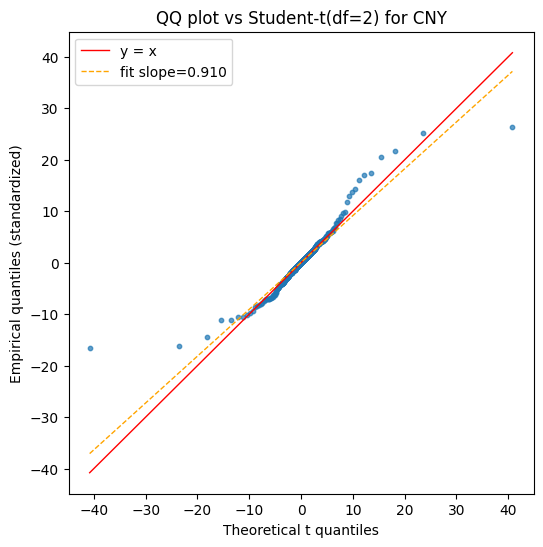

  Fit slope=0.9100, intercept=0.0467
------------------------------------------------------------


In [27]:
#Generated using VS copilot
# Test for Student's t distribution (no parameter fitting: use robust standardization)

def test_student_t(name, data, df=2, alpha=alpha, n_boot=0, random_state=0):
    x = np.asarray(data).ravel()
    x = x[~np.isnan(x)]
    n = x.size
    print(f"Student-t (df={df}) QQ for {name} (n={n}):")

    # Robust location/scale using median and IQR mapped to theoretical t-IQR (no fitting)
    med_emp = np.median(x)
    emp_q75, emp_q25 = np.percentile(x, [75, 25])
    th_q75, th_q25 = stats.t.ppf([0.75, 0.25], df)
    denom = (th_q75 - th_q25)
    if denom == 0:
        scale = np.std(x) if np.std(x) > 0 else 1.0
    else:
        scale = (emp_q75 - emp_q25) / denom
        if scale == 0:
            scale = np.std(x) if np.std(x) > 0 else 1.0

    # Standardize data using robust loc/scale (this is NOT fitting distribution parameters)
    z = (x - med_emp) / scale

    # QQ plot: theoretical t quantiles vs empirical quantiles of standardized data
    z_sorted = np.sort(z)
    probs = (np.arange(1, n + 1) - 0.5) / n
    th_q = stats.t.ppf(probs, df)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(th_q, z_sorted, s=10, alpha=0.7)
    # identity line
    xmin, xmax = np.nanmin(th_q), np.nanmax(th_q)
    ax.plot([xmin, xmax], [xmin, xmax], color='r', lw=1, label='y = x')
    # fitted line for guidance
    m, b = np.polyfit(th_q, z_sorted, 1)
    ax.plot([xmin, xmax], [m * xmin + b, m * xmax + b], color='orange', lw=1, ls='--', label=f'fit slope={m:.3f}')
    ax.set_xlabel('Theoretical t quantiles')
    ax.set_ylabel('Empirical quantiles (standardized)')
    ax.set_title(f'QQ plot vs Student-t(df={df}) for {name}')
    ax.legend()
    plt.show()

    print(f"  Fit slope={m:.4f}, intercept={b:.4f}")
    print("-" * 60)

for name, arr in [('USD', usd_rets), ('EUR', eur_rets), ('CNY', cny_rets)]:
    test_student_t(name, arr, df=2, alpha=alpha)


USD: fitted df=2.0854, loc=0.0001, scale=0.0052
EUR: fitted df=1.8830, loc=-0.0000, scale=0.0051
CNY: fitted df=1.8743, loc=-0.0000, scale=0.0048


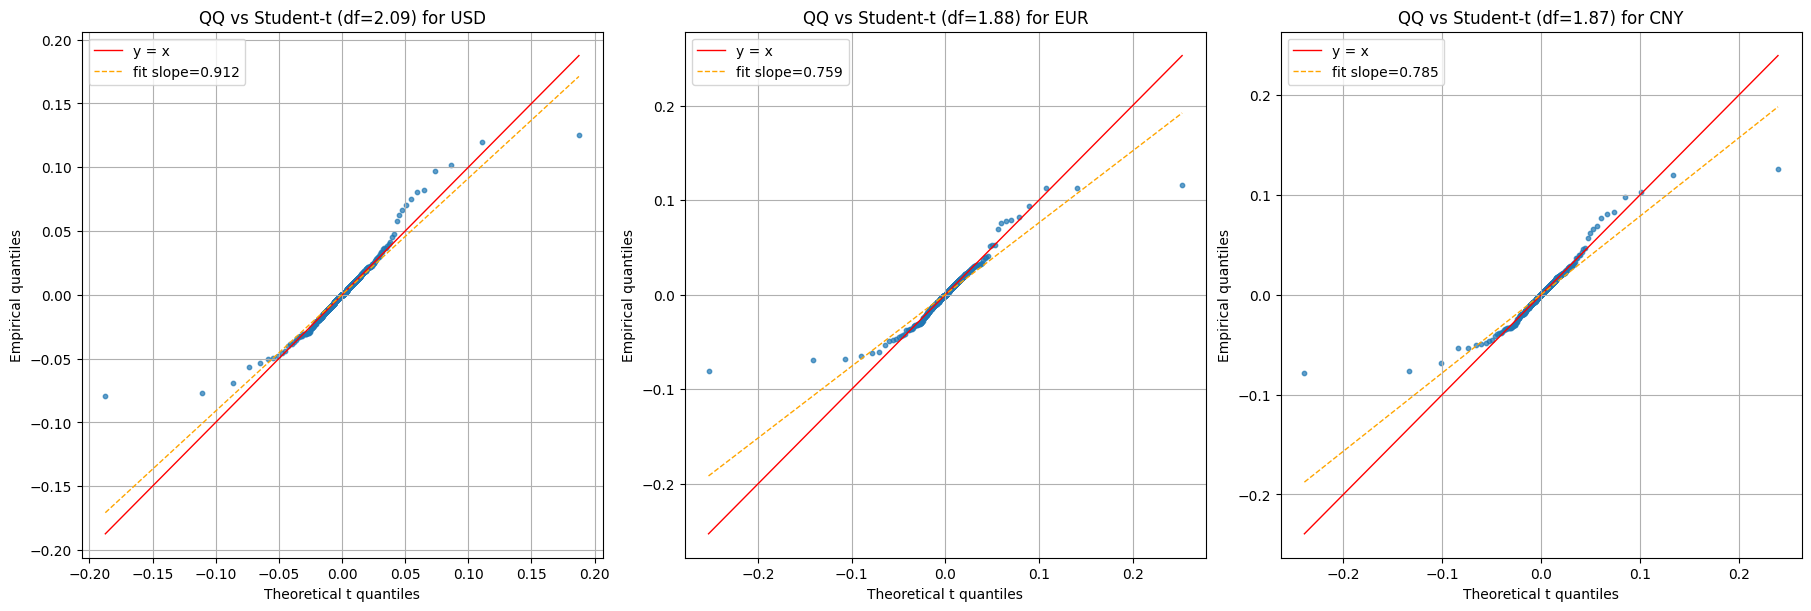

In [29]:
# QQ plots vs fitted Student-t for USD/EUR/CNY returns
# Uses existing variables: usd_rets, eur_rets, cny_rets, stats, plt, np

def fit_student_t_params(x):
    x = np.asarray(x).ravel()
    x = x[~np.isnan(x)]
    # require enough points
    if x.size < 10:
        raise ValueError("not enough data to fit")
    # initial guess via robust moments
    try:
        # scipy's fit may be unstable; guard with try/except
        df_hat, loc_hat, scale_hat = stats.t.fit(x)
        # ensure reasonable scale and df
        if scale_hat <= 0 or df_hat <= 0:
            raise RuntimeError("unreasonable fit results")
        return float(df_hat), float(loc_hat), float(scale_hat)
    except Exception:
        # fallback: robust location/scale and a moderately heavy tail df
        med = np.median(x)
        q75, q25 = np.percentile(x, [75, 25])
        iqr = q75 - q25
        # theoretical IQR for t with df=4 (as baseline)
        th_iqr_df4 = stats.t.ppf(0.75, 4) - stats.t.ppf(0.25, 4)
        scale = iqr / th_iqr_df4 if th_iqr_df4 > 0 else np.std(x) or 1.0
        return 4.0, float(med), float(scale)

def qq_plot_student(name, data, ax=None):
    x = np.asarray(data).ravel()
    x = x[~np.isnan(x)]
    n = x.size
    if n == 0:
        raise ValueError(f"No data for {name}")
    df_hat, loc_hat, scale_hat = fit_student_t_params(x)

    probs = (np.arange(1, n + 1) - 0.5) / n
    th_q = stats.t.ppf(probs, df_hat, loc=loc_hat, scale=scale_hat)
    emp_q = np.sort(x)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(th_q, emp_q, s=10, alpha=0.7)
    # identity line (in sample space)
    mn = np.nanmin([th_q.min(), emp_q.min()])
    mx = np.nanmax([th_q.max(), emp_q.max()])
    ax.plot([mn, mx], [mn, mx], color='r', lw=1, label='y = x')
    # fitted regression line for guidance
    m, b = np.polyfit(th_q, emp_q, 1)
    ax.plot([mn, mx], [m * mn + b, m * mx + b], color='orange', lw=1, ls='--',
            label=f'fit slope={m:.3f}')
    ax.set_title(f'QQ vs Student-t (df={df_hat:.2f}) for {name}')
    ax.set_xlabel('Theoretical t quantiles')
    ax.set_ylabel('Empirical quantiles')
    ax.legend()
    ax.grid(True)
    # print fitted params
    print(f"{name}: fitted df={df_hat:.4f}, loc={loc_hat:.4f}, scale={scale_hat:.4f}")

# Create a 1x3 figure and plot all three
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
qq_plot_student('USD', usd_rets, ax=axes[0])
qq_plot_student('EUR', eur_rets, ax=axes[1])
qq_plot_student('CNY', cny_rets, ax=axes[2])
plt.show()

USD: fitted genhyperbolic params -> p=-0.7963, a=0.1097, b=0.0115, loc=-0.0001, scale=0.0062
EUR: fitted genhyperbolic params -> p=-0.7281, a=0.1191, b=0.0124, loc=-0.0001, scale=0.0060
CNY: fitted genhyperbolic params -> p=-0.8046, a=0.0888, b=0.0105, loc=-0.0001, scale=0.0059


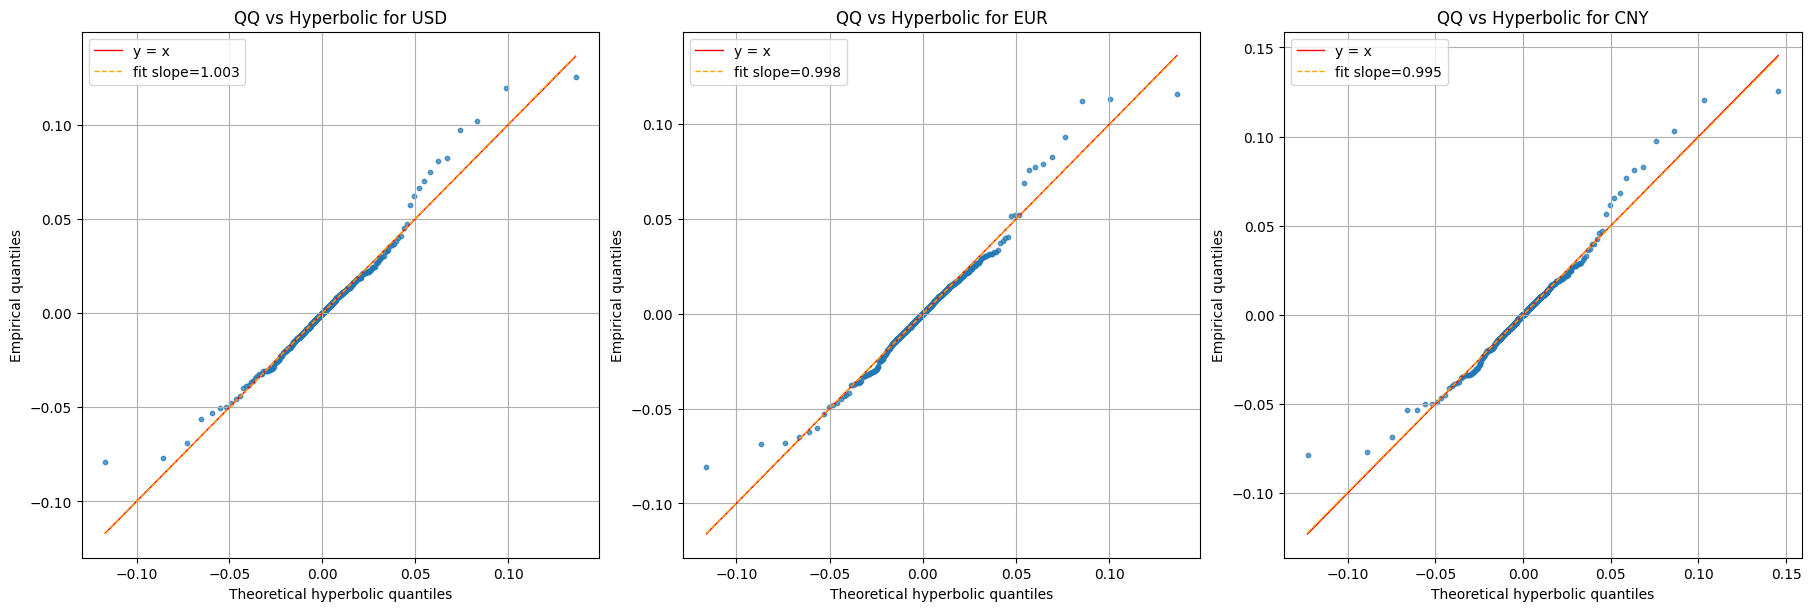

In [30]:
# QQ plots of USD/EUR/CNY returns vs Hyperbolic (generalized hyperbolic with fit)
# Uses existing variables: usd_rets, eur_rets, cny_rets, stats, plt, np

def qq_plot_hyperbolic(name, data, ax=None):
    x = np.asarray(data).ravel()
    x = x[~np.isnan(x)]
    n = x.size
    if n == 0:
        raise ValueError(f"No data for {name}")

    # Fit generalized-hyperbolic (hyperbolic is a special case) -> shapes: p, a, b, loc, scale
    try:
        params = stats.genhyperbolic.fit(x)
    except Exception as e:
        # fallback to a reasonable default if fit fails
        med = float(np.median(x))
        scl = float(np.std(x)) if np.std(x) > 0 else 1.0
        params = (1.0, 1.0, 0.0, med, scl)
        print(f"Warning: genhyperbolic.fit failed for {name}, using fallback params ({e})")

    probs = (np.arange(1, n + 1) - 0.5) / n
    try:
        th_q = stats.genhyperbolic.ppf(probs, *params)
    except Exception as e:
        # if ppf fails, warn and abort this plot
        print(f"Error computing ppf for {name} with params={params}: {e}")
        return

    emp_q = np.sort(x)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(th_q, emp_q, s=10, alpha=0.7)
    mn = np.nanmin([th_q.min(), emp_q.min()])
    mx = np.nanmax([th_q.max(), emp_q.max()])
    ax.plot([mn, mx], [mn, mx], color='r', lw=1, label='y = x')
    # regression line for guidance
    try:
        m, b = np.polyfit(th_q, emp_q, 1)
        ax.plot([mn, mx], [m * mn + b, m * mx + b], color='orange', lw=1, ls='--',
                label=f'fit slope={m:.3f}')
    except Exception:
        m = b = np.nan

    ax.set_title(f'QQ vs Hyperbolic for {name}')
    ax.set_xlabel('Theoretical hyperbolic quantiles')
    ax.set_ylabel('Empirical quantiles')
    ax.legend()
    ax.grid(True)

    # print fitted params (p, a, b, loc, scale)
    try:
        p, a, bsh, loc, scale = params
        print(f"{name}: fitted genhyperbolic params -> p={p:.4f}, a={a:.4f}, b={bsh:.4f}, loc={loc:.4f}, scale={scale:.4f}")
    except Exception:
        print(f"{name}: fitted params = {params}")

# Create a 1x3 figure and plot all three
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
qq_plot_hyperbolic('USD', usd_rets, ax=axes[0])
qq_plot_hyperbolic('EUR', eur_rets, ax=axes[1])
qq_plot_hyperbolic('CNY', cny_rets, ax=axes[2])
plt.show()